In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install optuna

import os
import gc
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Input, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# ==========================================
# CONFIGURAÇÕES GLOBAIS
# ==========================================
# Atualizado para o novo arquivo gerado no passo de preparação
DATASET_PATH = "/content/drive/MyDrive/2026/ic/npz_files/utd_mhad_v2.npz"
SEED = 42
N_BOOTSTRAP = 100

def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(SEED)


In [ ]:
# ==========================================
# 1. CARREGAMENTO E PREPARAÇÃO
# ==========================================
def load_data(path):
    print(f"Carregando: {path}...")
    try:
        data = np.load(path, allow_pickle=True)
        X_train = data['X_train']
        y_train = data['y_train']
        X_val = data['X_val']
        y_val = data['y_val']
        X_test = data['X_test']
        y_test = data['y_test']

        # One-Hot Encoding para Keras
        NUM_CLASSES = len(np.unique(y_train))
        y_train_cat = to_categorical(y_train, NUM_CLASSES)
        y_val_cat = to_categorical(y_val, NUM_CLASSES)
        y_test_cat = to_categorical(y_test, NUM_CLASSES)

        print(f"   Treino: {X_train.shape} | Validação: {X_val.shape} | Teste: {X_test.shape} | Classes: {NUM_CLASSES}")
        return X_train, y_train_cat, X_val, y_val_cat, X_test, y_test_cat, NUM_CLASSES, y_test # Retorna y_test original para métricas
    except Exception as e:
        print(f"Erro ao carregar dados: {e}")
        return None

def prep_dl_data(X_train, X_val, X_test, mode='raw'):
    """
    mode='raw': CNN-1D (Repassa os dados pois já foram normalizados na preparação)
    mode='features': MLP (Extrai features e normaliza 2D)
    """
    scaler = StandardScaler()

    if mode == 'raw':
        # Como o utd_mhad_v2.npz já vem normalizado (ver script de preparação),
        # não precisamos aplicar outro StandardScaler aqui, evitamos distorcer os dados.
        return X_train.copy(), (X_val.copy() if X_val is not None else None), X_test.copy()

    elif mode == 'features':
        # Função interna de extração
        def extract(X):
            if X is None: return None
            # Extrai Mean, Std, Max, Min ao longo do tempo (eixo 1)
            return np.hstack([
                np.mean(X, axis=1), np.std(X, axis=1),
                np.max(X, axis=1), np.min(X, axis=1)
            ])

        X_tr_feat = extract(X_train)
        X_te_feat = extract(X_test)
        X_val_feat = extract(X_val)

        # Aqui aplicamos o fit_transform nas features extraídas, mesmo que a base estivesse normalizada,
        # pois a distribuição destas novas variáveis derivadas pode não estar em mean=0, std=1
        X_tr_sc = scaler.fit_transform(X_tr_feat)
        X_te_sc = scaler.transform(X_te_feat)
        X_val_sc = scaler.transform(X_val_feat) if X_val_feat is not None else None

        return X_tr_sc, X_val_sc, X_te_sc


In [ ]:
# ==========================================
# 2. CONSTRUÇÃO DE MODELOS
# ==========================================
def build_cnn(input_shape, num_classes, params={}):
    # Defaults
    filters_1 = params.get('filters_1', 64)
    kernel_1 = params.get('kernel_1', 3)
    filters_2 = params.get('filters_2', 128)
    kernel_2 = params.get('kernel_2', 3)
    dense_units = params.get('dense_units', 64)
    dropout = params.get('dropout', 0.5)
    lr = params.get('lr', 0.001)

    model = Sequential([
        Input(shape=input_shape),
        Conv1D(filters=filters_1, kernel_size=kernel_1, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Conv1D(filters=filters_2, kernel_size=kernel_2, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        GlobalAveragePooling1D(), # Ou Flatten
        Dense(dense_units, activation='relu'),
        Dropout(dropout),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_mlp(input_shape, num_classes, params={}):
    # Defaults
    units_1 = params.get('units_1', 128)
    units_2 = params.get('units_2', 64)
    dropout = params.get('dropout', 0.5)
    lr = params.get('lr', 0.001)

    model = Sequential([
        Input(shape=input_shape),
        Dense(units_1, activation='relu'),
        BatchNormalization(),
        Dropout(dropout),

        Dense(units_2, activation='relu'),
        BatchNormalization(),
        Dropout(dropout),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
# ==========================================
# 3. OPTUNA
# ==========================================
def run_optuna_dl(X_train, y_train, X_val, y_val, mode, num_classes, n_trials=10):

    def objective(trial):
        tf.keras.backend.clear_session()

        # Espaço de busca comum
        lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        dropout = trial.suggest_float('dropout', 0.1, 0.5)
        weight_factor = trial.suggest_float('weight_factor', 0.1, 5.0)

        params = {'lr': lr, 'dropout': dropout, 'weight_factor': weight_factor}

        if mode == 'raw':
            params.update({
                'filters_1': trial.suggest_categorical('filters_1', [32, 64]),
                'kernel_1': trial.suggest_int('kernel_1', 3, 9, step=2),
                'filters_2': trial.suggest_categorical('filters_2', [64, 128]),
                'kernel_2': trial.suggest_int('kernel_2', 3, 7, step=2),
                'dense_units': trial.suggest_int('dense_units', 32, 128)
            })
            model = build_cnn(X_train.shape[1:], num_classes, params)
        else:
            params.update({
                'units_1': trial.suggest_int('units_1', 64, 256),
                'units_2': trial.suggest_int('units_2', 32, 128)
            })
            model = build_mlp(X_train.shape[1:], num_classes, params)

        # Converte o weight_factor gerado em um dicionário para o Keras
        class_weights = {i: float(1.0 if i == 0 else weight_factor) for i in range(num_classes)}

        # Treino curto para otimização
        es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=15,
            batch_size=64,
            verbose=0,
            class_weight=class_weights,
            callbacks=[es]
        )

        # Predição no conjunto de validação para calcular o F1-Macro
        y_pred_probs = model.predict(X_val, verbose=0)
        y_pred_val = np.argmax(y_pred_probs, axis=1)
        y_true_val = np.argmax(y_val, axis=1)

        val_f1 = f1_score(y_true_val, y_pred_val, average='macro')
        return val_f1

    print(f"   [Optuna] Otimizando {mode.upper()}...")
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)

    print(f"   [Optuna] Melhores Params: {study.best_params}")
    return study.best_params


Carregando: /content/drive/MyDrive/2026/ic/npz_files/utd_mhad_v2.npz...
   Treino: (457, 125, 66) | Validação: (145, 125, 66) | Teste: (623, 125, 66) | Classes: 27

>>> EXECUTANDO: CNN (Raw) - Default <<<
   [Bootstrap] F1-Score: 0.5243 (IC: 0.4969-0.5586)
   [Bootstrap] Acurácia: 0.5676 (IC: 0.5295-0.6037)

>>> EXECUTANDO: CNN (Raw) - Optuna <<<
   [Optuna] Otimizando RAW...
   [Optuna] Melhores Params: {'lr': 0.000666001949184115, 'dropout': 0.41940621180889326, 'weight_factor': 4.254365759941453, 'filters_1': 64, 'kernel_1': 5, 'filters_2': 64, 'kernel_2': 5, 'dense_units': 112}
   [Bootstrap] F1-Score: 0.4278 (IC: 0.3972-0.4622)
   [Bootstrap] Acurácia: 0.4652 (IC: 0.4261-0.5025)

>>> EXECUTANDO: MLP (Features) - Default <<<
   [Bootstrap] F1-Score: 0.6340 (IC: 0.5906-0.6688)
   [Bootstrap] Acurácia: 0.6780 (IC: 0.6323-0.7135)

>>> EXECUTANDO: MLP (Features) - Optuna <<<
   [Optuna] Otimizando FEATURES...
   [Optuna] Melhores Params: {'lr': 0.009844510904100849, 'dropout': 0.305561

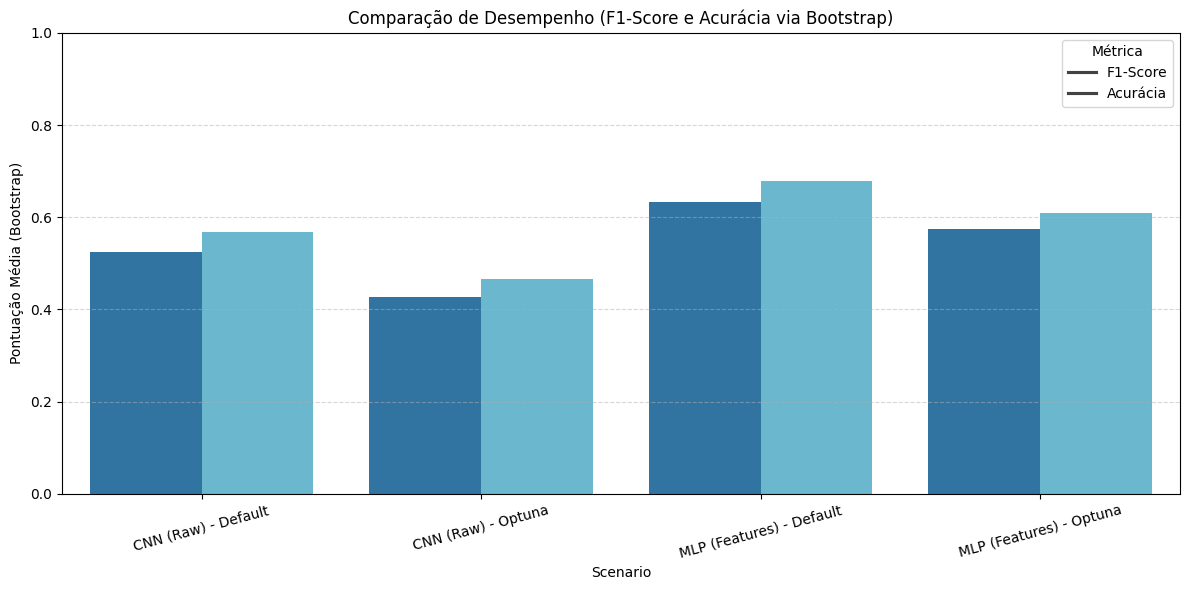

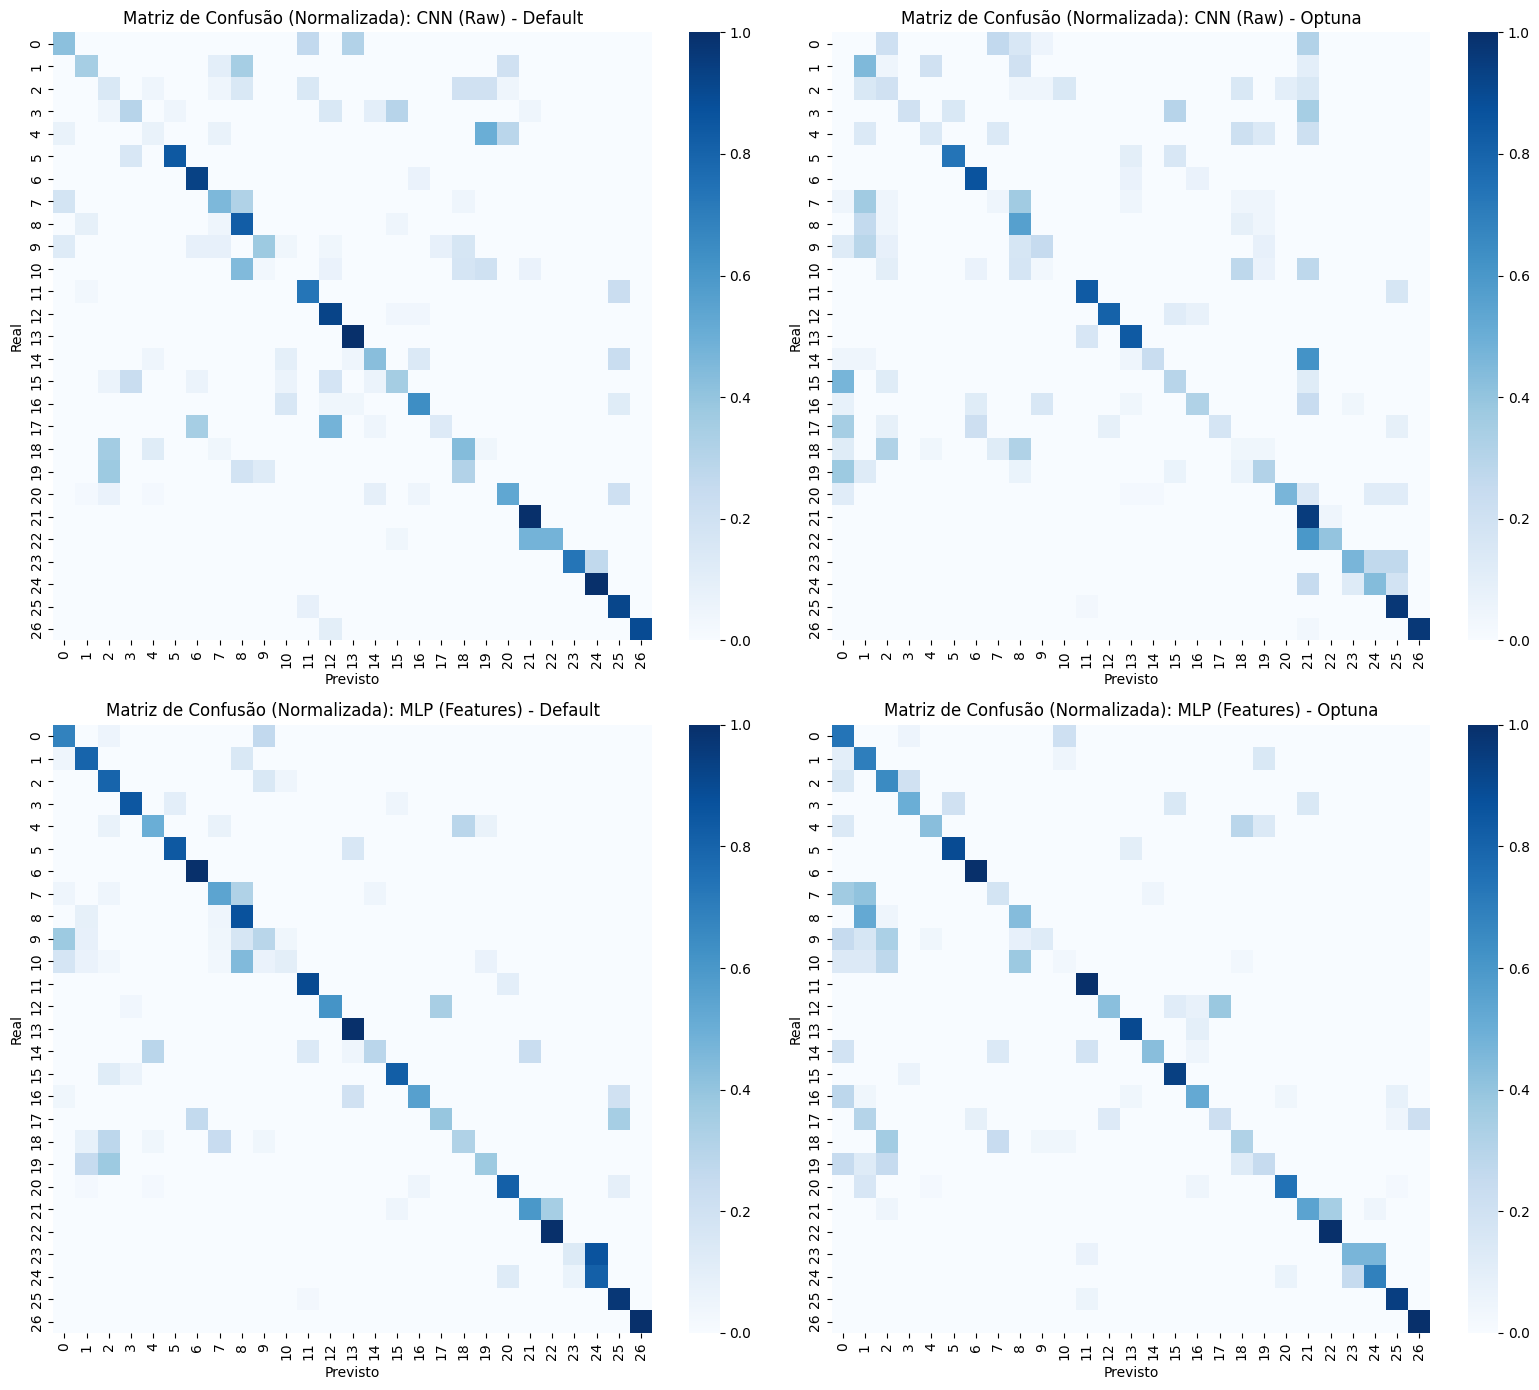

In [ ]:
# ==============================================================================
# LOOP DE EXECUÇÃO (DEEP LEARNING: CNN & MLP)
# ==============================================================================
results = []

# Carregando os dados
X_train, y_train, X_val, y_val, X_test, y_test_cat, NUM_CLASSES, y_te_labels = load_data(DATASET_PATH)

# Definindo os cenários a serem testados
scenarios = [
    ('CNN (Raw) - Default', 'raw', False),
    ('CNN (Raw) - Optuna', 'raw', True),
    ('MLP (Features) - Default', 'features', False),
    ('MLP (Features) - Optuna', 'features', True)
]

for label, mode, use_optuna in scenarios:
    print(f"\n>>> EXECUTANDO: {label} <<<")
    start_time = time.time()

    # A. Otimização ou Default
    if use_optuna:
        # Prepara os dados repassando X_val explícito para não usar split interno
        X_tr_o_sc, X_val_o_sc, _ = prep_dl_data(X_train, X_val, X_test, mode)
        best_params = run_optuna_dl(X_tr_o_sc, y_train, X_val_o_sc, y_val, mode, NUM_CLASSES, n_trials=10)
    else:
        best_params = {}

    # B. Treino Final
    # Agora utilizando X_val_final em vez de None para o Early Stopping
    X_tr_final, X_val_final, X_te_final = prep_dl_data(X_train, X_val, X_test, mode)

    if mode == 'raw':
        model = build_cnn(X_tr_final.shape[1:], NUM_CLASSES, best_params)
    else:
        model = build_mlp(X_tr_final.shape[1:], NUM_CLASSES, best_params)

    # Converte o weight_factor para dicionário (usando 1.0 como default para o cenário sem Optuna)
    w_factor = best_params.get('weight_factor', 1.0)
    class_weights = {i: float(1.0 if i == 0 else w_factor) for i in range(NUM_CLASSES)}

    es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

    # Treino: Corrigido para USAR o X_val em vez de validation_split=0.1 (evita vazamento de sujeitos)
    model.fit(
        X_tr_final, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_val_final, y_val),
        verbose=0,
        class_weight=class_weights,
        callbacks=[es]
    )

    # C. Predições
    y_pred_probs = model.predict(X_te_final, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Normaliza por classe real (linhas) para lidar com o desbalanceamento
    cm = confusion_matrix(y_te_labels, y_pred, normalize='true')

    # D. Avaliação via Bootstrap (F1 + Accuracy)
    boot_f1_scores = []
    boot_acc_scores = []

    for i in range(N_BOOTSTRAP):
        indices = resample(np.arange(len(y_te_labels)), random_state=i)
        y_true_boot = y_te_labels[indices]
        y_pred_boot = y_pred[indices]

        boot_f1_scores.append(f1_score(y_true_boot, y_pred_boot, average='macro'))
        boot_acc_scores.append(accuracy_score(y_true_boot, y_pred_boot))

    # Stats
    f1_mean = np.mean(boot_f1_scores)
    f1_low = np.percentile(boot_f1_scores, 2.5)
    f1_high = np.percentile(boot_f1_scores, 97.5)

    acc_mean = np.mean(boot_acc_scores)
    acc_low = np.percentile(boot_acc_scores, 2.5)
    acc_high = np.percentile(boot_acc_scores, 97.5)

    elapsed = time.time() - start_time
    print(f"   [Bootstrap] F1-Score: {f1_mean:.4f} (IC: {f1_low:.4f}-{f1_high:.4f})")
    print(f"   [Bootstrap] Acurácia: {acc_mean:.4f} (IC: {acc_low:.4f}-{acc_high:.4f})")

    results.append({
        "Scenario": label,
        "F1_Mean": f1_mean,
        "F1_Lower": f1_low,
        "F1_Upper": f1_high,
        "Acc_Mean": acc_mean,
        "Acc_Lower": acc_low,
        "Acc_Upper": acc_high,
        "Time_Sec": elapsed,
        "CM": cm
    })

    tf.keras.backend.clear_session()
    gc.collect()

# ==============================================================================
# RELATÓRIO E GRÁFICO FINAL
# ==============================================================================
df_res = pd.DataFrame(results)
print("\n\n=== RELATÓRIO FINAL: DEEP LEARNING (UTD-MHAD) ===")
print(df_res[['Scenario', 'F1_Mean', 'Acc_Mean', 'Time_Sec']])

# Gráfico de Barras Azuis (Comparando F1 e Acc)
df_melt = df_res.melt(id_vars='Scenario', value_vars=['F1_Mean', 'Acc_Mean'],
                      var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melt, x='Scenario', y='Score', hue='Metric', palette=['#1f77b4', '#5bc0de'])
plt.title("Comparação de Desempenho (F1-Score e Acurácia via Bootstrap)")
plt.ylabel("Pontuação Média (Bootstrap)")
plt.ylim(0.0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=15)
plt.legend(title='Métrica', labels=['F1-Score', 'Acurácia'])
plt.tight_layout()
plt.show()

# Matrizes de Confusão Normalizadas
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()
for idx, res in enumerate(results):
    sns.heatmap(res['CM'], annot=False, cmap='Blues', ax=axes[idx], cbar=True, vmin=0, vmax=1)
    axes[idx].set_title(f"Matriz de Confusão (Normalizada): {res['Scenario']}")
    axes[idx].set_xlabel('Previsto')
    axes[idx].set_ylabel('Real')
plt.tight_layout()
plt.show()
